# Datasplitting and Moving it into Different Ddirectories

In [1]:
import pandas as pd
import numpy as np
from Ch_1_Data_Preparation.DataSplittingHelper import *

In [2]:
manifest = pd.read_csv(r"realized_manifest_cleaned.csv", index_col=0)

In [3]:
manifest

,country,buildingType,surrounding,buildingAgeBin,a_ref,n_apartments,year_type,future,climateRegion,n_persons,...,state_seed,apartment_seeds,appliances,maxLoadViolation_kW,runtime_seconds,resolved_year,n_persons_sum,appliances_unique,building_id,run_id
0,DE,AB,Terraced,DE.02,1340.9,14,average,True,5,"[2, 2, 1, 4, 1, 1, 2, 1, 3, 3, 1, 4, 1, 2]",...,1000000,"[1341242, 2161857, 7980730, 3141875, 8938643, ...","[['UPRIGHT_FREEZER', 'ANSWER_MACHINE', 'CD_PLA...",6.166263e-11,492.192459,2018,28,"['UPRIGHT_FREEZER', 'ANSWER_MACHINE', 'CD_PLAY...",0,run_000000
1,DE,AB,Terraced,DE.02,1340.9,14,average,True,5,"[2, 2, 1, 4, 1, 1, 2, 1, 3, 3, 1, 4, 1, 2]",...,1000001,"[7816614, 6767105, 9804180, 7763681, 9544759, ...","[['FRIDGE_FREEZER', 'FRIDGE', 'ANSWER_MACHINE'...",9.397497e-14,507.807770,2021,28,"['FRIDGE_FREEZER', 'FRIDGE', 'ANSWER_MACHINE',...",0,run_000001
2,DE,AB,Terraced,DE.02,1340.9,14,average,True,5,"[2, 2, 1, 4, 1, 1, 2, 1, 3, 3, 1, 4, 1, 2]",...,1000002,"[5393235, 3905184, 5287101, 2391082, 5770489, ...","[['FRIDGE', 'ANSWER_MACHINE', 'CD_PLAYER', 'CL...",8.456416e-11,514.073798,2023,28,"['FRIDGE', 'ANSWER_MACHINE', 'CD_PLAYER', 'CLO...",0,run_000002
3,DE,AB,Terraced,DE.02,1340.9,14,average,True,5,"[2, 2, 1, 4, 1, 1, 2, 1, 3, 3, 1, 4, 1, 2]",...,1000003,"[4220299, 2206534, 5895420, 6297306, 4210654, ...","[['FRIDGE', 'ANSWER_MACHINE', 'CLOCK', 'PHONE'...",1.826148e-09,505.372323,2025,28,"['FRIDGE', 'ANSWER_MACHINE', 'CLOCK', 'PHONE',...",0,run_000003
4,DE,AB,Terraced,DE.02,1728.9,18,average,False,6,"[2, 4, 2, 1, 1, 1, 1, 2, 1, 2, 2, 2, 1, 3, 2, ...",...,1000004,"[5649322, 6969250, 429204, 9004735, 194318, 10...","[['CHEST_FREEZER', 'FRIDGE_FREEZER', 'ANSWER_M...",1.339297e-11,627.279614,2018,31,"['CHEST_FREEZER', 'FRIDGE_FREEZER', 'ANSWER_MA...",1,run_000004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15991,DE,TH,Semi,DE.12,57.1,1,hot,False,6,[2],...,1015995,[8387292],"[['FRIDGE', 'CD_PLAYER', 'CLOCK', 'HIFI', 'VAC...",6.127615e-11,55.835199,2025,2,"['FRIDGE', 'CD_PLAYER', 'CLOCK', 'HIFI', 'VACU...",3998,run_015995
15992,DE,TH,Semi,DE.12,150.9,2,hot,True,12,"[2, 2]",...,1015996,"[2521613, 5322742]","[['FRIDGE_FREEZER', 'ANSWER_MACHINE', 'CD_PLAY...",4.253758e-12,88.166542,2018,4,"['FRIDGE_FREEZER', 'ANSWER_MACHINE', 'CD_PLAYE...",3999,run_015996
15993,DE,TH,Semi,DE.12,150.9,2,hot,True,12,"[2, 2]",...,1015997,"[7075494, 739411]","[['FRIDGE_FREEZER', 'ANSWER_MACHINE', 'CD_PLAY...",8.694240e-16,86.841710,2021,4,"['FRIDGE_FREEZER', 'ANSWER_MACHINE', 'CD_PLAYE...",3999,run_015997
15994,DE,TH,Semi,DE.12,150.9,2,hot,True,12,"[2, 2]",...,1015998,"[4608605, 6561478]","[['FRIDGE', 'ANSWER_MACHINE', 'CD_PLAYER', 'CL...",4.815420e-13,91.391708,2023,4,"['FRIDGE', 'ANSWER_MACHINE', 'CD_PLAYER', 'CLO...",3999,run_015998


## Defince Cols and Splitdata with holdout

In [4]:
# ToDO holdout for year
strat_cols = ["buildingType", "buildingAgeBin"]
strat_cols_test = ["buildingType", "buildingAgeBin", "climateRegion","year_type","future"]
rest_cols = ["a_ref", "n_persons_sum", "n_apartments"]
buildings, train_idx, val_idx, test_idx, train_buildings,val_buildings,test_buildings  ,train_df, val_df, test_df, holdout_buildings_idx, holdout_building_df, holdout_year_df, holdout_both_df = split_manifests(manifest, strat_cols,holdout_type="TH", holdout_age="DE.05", fractions=[0.7, 0.15, 0.15], holdout_year=2021)

split_dfs = {
    "train": train_df, "val": val_df, "test": test_df,
    "holdout_building": holdout_building_df,
    "holdout_year": holdout_year_df,
    "holdout_both": holdout_both_df,
}

buildings -> train 2730, val 585, test 585
rows-> train 8187, val 1755, test 1755
rows-> holdout_building 300, holdout_year 3899, holdout_both 100


## Check wether distribution is still somewhat equal

___a_ref___
       original    train      val     test  holdout_building  holdout_year  \
count   3900.00  2730.00   585.00   585.00            100.00       3899.00   
mean     482.43   482.85   478.53   484.33            146.80        482.51   
std      512.03   512.72   513.82   507.83             67.59        512.07   
min       20.10    20.10    24.20    24.90             34.70         20.10   
25%      107.48   105.72   108.40   112.70             90.28        107.45   
50%      200.65   202.20   197.30   196.60            131.25        200.70   
75%      783.42   779.10   780.60   799.90            196.25        783.75   
max     2247.90  2247.90  2134.00  2038.30            280.80       2247.90   

       holdout_both  
count        100.00  
mean         146.80  
std           67.59  
min           34.70  
25%           90.28  
50%          131.25  
75%          196.25  
max          280.80  
train: stat=0.0058, p=1.0000
val: stat=0.0221, p=0.9597
test: stat=0.0290, p=0.7754
___

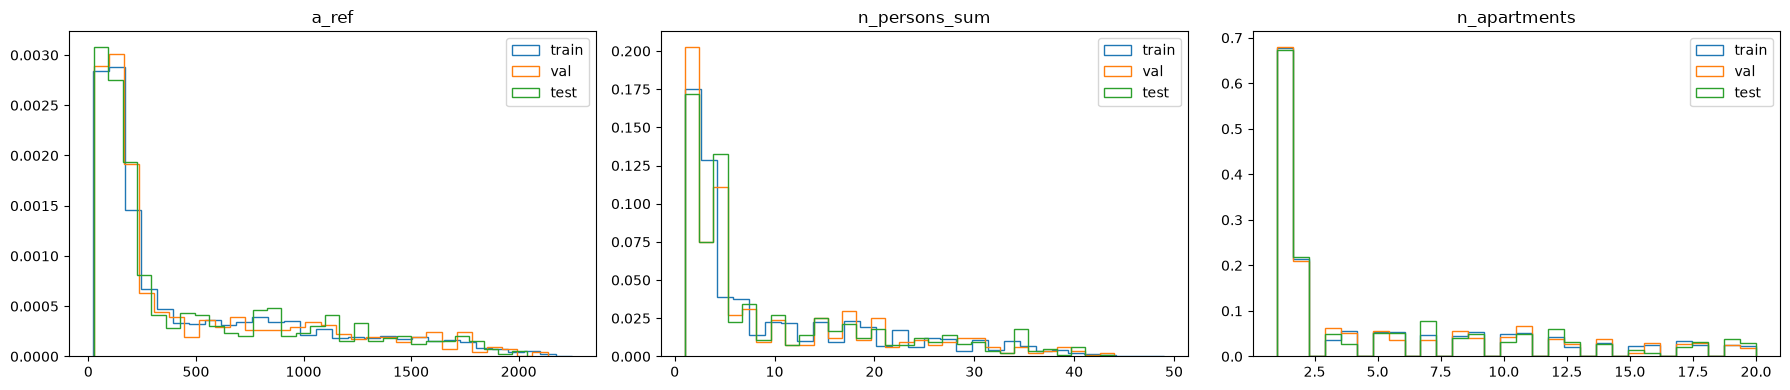

___buildingType___
              original  train   val  test  holdout_building  holdout_year  \
buildingType                                                                
AB                0.13   0.13  0.13  0.13               NaN          0.13   
MFH               0.31   0.31  0.31  0.31               NaN          0.31   
SFH               0.31   0.31  0.31  0.31               NaN          0.31   
TH                0.26   0.26  0.26  0.26               1.0          0.26   

              holdout_both  
buildingType                
AB                     NaN  
MFH                    NaN  
SFH                    NaN  
TH                     1.0  
Chi2=0.0000, p=1.0000, dof=6
___buildingAgeBin___
                original  train   val  test  holdout_building  holdout_year  \
buildingAgeBin                                                                
DE.01               0.05   0.05  0.05  0.05               NaN          0.05   
DE.02               0.10   0.10  0.10  0.10              

In [5]:
check_distr(split_dfs=split_dfs,cont_cols=rest_cols, cat_cols=strat_cols_test, row_cols=["year"])

## Move spplite files to directories

In [6]:
source_dir = Path(r"../Ch_1_Data_Preparation/Generation")
target_root = Path(r"../DataSplit/Data")

split_dirs = {
    "train": target_root/"train",
    "val": target_root/"val",
    "test": target_root/"test",
    "holdout_year": target_root/"test"/"holdout_year",
    "holdout_building": target_root/"test"/"holdout_building",
    "holdout_both": target_root/"test"/"holdout_both",
}

split_dfs = {
    "train": train_df, "val": val_df, "test": test_df,
    "holdout_building": holdout_building_df,
    "holdout_year": holdout_year_df,
    "holdout_both": holdout_both_df,
}

move_split_data(manifest, source_dir,split_dirs, split_dfs)

In [7]:
train_df_exist, train_idx_missing = existing_filter(train_df, split_dirs["train"])

Missing Files: 7432
Existing Files: 755
Total: 8187


## Calculate Parameters for normalization once per resolution

In [8]:
# ToDo calculate all parameters in a loop add paramters used for other scalers min, max etc.

ALL_COLS = [
    "T",
    "Occupancy Home Active",
    "Occupancy Home Not Active",
    "Electricity Load",
    "Hot Water Load",
    "Heating Load",
]

TS_AGG = {
    "T": "first",
    "Occupancy Home Active": "first",
    "Occupancy Home Not Active": "first",
    "Electricity Load": "mean",
    "Hot Water Load": "mean",
    "Heating Load": "mean",
}

#means, stds = calc_mean_std(train_files,ALL_COLS,resolution=None, aggregation=TS_AGG)
#save_stats("stats_1min.npz", cols=ALL_COLS, res=None, mean=means, std=stds)

In [9]:
run_ids = train_df_exist["run_id"].tolist()
files = [Path(split_dirs["train"]) / f"{run_id}.h5" for run_id in run_ids]


In [10]:
len(files)

755

In [11]:
stats=calc_scaler_stats(files,run_ids,ALL_COLS,resolution=None, aggregation=TS_AGG)

  0%|          | 0/755 [00:00<?, ?it/s]

In [12]:
def save_stats(path, res, cols, stats):
    np.savez(Path(path), columns=np.array(cols), resolution=str(res), **stats)

In [13]:
stats

{'mean': array([ 9.56479061,  5.21185786,  5.07841609,  2.55924067,  1.17006705,
        13.840571  ]),
 'std': array([ 8.03755321,  6.4494073 ,  8.58901518,  2.9868079 ,  5.43053214,
        22.39027252]),
 'min': array([-2.13999996e+01,  0.00000000e+00,  0.00000000e+00,  1.70728993e-02,
         0.00000000e+00,  0.00000000e+00]),
 'max': array([ 38.70000076,  43.        ,  49.        ,  35.34933472,
        227.80712891, 219.33622742]),
 'log_mean': array([       nan, 1.29924821, 1.04157637, 0.97157945, 0.1779588 ,
        1.60887465]),
 'log_std': array([       nan, 1.0429605 , 1.15754132, 0.75340257, 0.69436206,
        1.51014547]),
 'q0.01': array([-7.36499977e+00,  0.00000000e+00,  0.00000000e+00,  3.80385667e-02,
         0.00000000e+00,  1.18244054e-14]),
 'q0.25': array([3.39499998e+00, 0.00000000e+00, 0.00000000e+00, 3.01745333e-01,
        0.00000000e+00, 2.48273740e-09]),
 'q0.5': array([9.39999962, 2.        , 1.        , 1.42009795, 0.        ,
        3.15939927]),
 'q0

In [14]:
save_stats("stats_1min.npz", cols=ALL_COLS,res=None,stats=stats)

In [15]:
load_stats("stats_1min.npz")

{'T': {'mean': 9.564790612665178,
  'std': 8.037553206445162,
  'min': -21.399999618530273,
  'max': 38.70000076293945,
  'log_mean': nan,
  'log_std': nan,
  'q0.01': -7.364999771118164,
  'q0.25': 3.3949999809265137,
  'q0.5': 9.399999618530273,
  'q0.75': 15.50333309173584,
  'q0.99': 27.65833282470703},
 'Occupancy Home Active': {'mean': 5.21185785781243,
  'std': 6.449407297314983,
  'min': 0.0,
  'max': 43.0,
  'log_mean': 1.2992482062625421,
  'log_std': 1.0429604986357068,
  'q0.01': 0.0,
  'q0.25': 0.0,
  'q0.5': 2.0,
  'q0.75': 8.0,
  'q0.99': 25.0},
 'Occupancy Home Not Active': {'mean': 5.078416089590451,
  'std': 8.589015177721913,
  'min': 0.0,
  'max': 49.0,
  'log_mean': 1.0415763717568804,
  'log_std': 1.1575413183798762,
  'q0.01': 0.0,
  'q0.25': 0.0,
  'q0.5': 1.0,
  'q0.75': 5.0,
  'q0.99': 34.0},
 'Electricity Load': {'mean': 2.5592406657877267,
  'std': 2.986807895483798,
  'min': 0.017072899267077446,
  'max': 35.349334716796875,
  'log_mean': 0.9715794513175496

In [17]:
NORM_BY_COL = {"Heating Load": "a_ref", "Hot Water Load": "n_persons_sum", "Electricity Load": "n_persons_sum"}
columns = ["Heating Load","Hot Water Load","Electricity Load"]

In [18]:
build_norm_factors(train_df, columns=columns, norm_by_col=NORM_BY_COL)

{'run_000000': array([[1340.9],
        [  28. ],
        [  28. ]], dtype=float32),
 'run_000002': array([[1340.9],
        [  28. ],
        [  28. ]], dtype=float32),
 'run_000003': array([[1340.9],
        [  28. ],
        [  28. ]], dtype=float32),
 'run_000008': array([[1388.2],
        [  24. ],
        [  24. ]], dtype=float32),
 'run_000010': array([[1388.2],
        [  24. ],
        [  24. ]], dtype=float32),
 'run_000011': array([[1388.2],
        [  24. ],
        [  24. ]], dtype=float32),
 'run_000016': array([[1336.8],
        [  26. ],
        [  26. ]], dtype=float32),
 'run_000018': array([[1336.8],
        [  26. ],
        [  26. ]], dtype=float32),
 'run_000019': array([[1336.8],
        [  26. ],
        [  26. ]], dtype=float32),
 'run_000024': array([[1679.2],
        [  36. ],
        [  36. ]], dtype=float32),
 'run_000026': array([[1679.2],
        [  36. ],
        [  36. ]], dtype=float32),
 'run_000027': array([[1679.2],
        [  36. ],
        [  36. 